# StellarStats — 02: Statistical Distributions

## Goal
Explore the statistical distributions of key stellar properties:
temperature, luminosity, radius, and absolute magnitude.
Identify skewness and test for log-normality.

In [1]:
# Core libraries for analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # For Shapiro-Wilk normality testing

# Load cleaned dataset produced in 01_EDA.ipynb
df = pd.read_csv('../data/hyg_clean.csv')
print(df.shape)

(107859, 38)


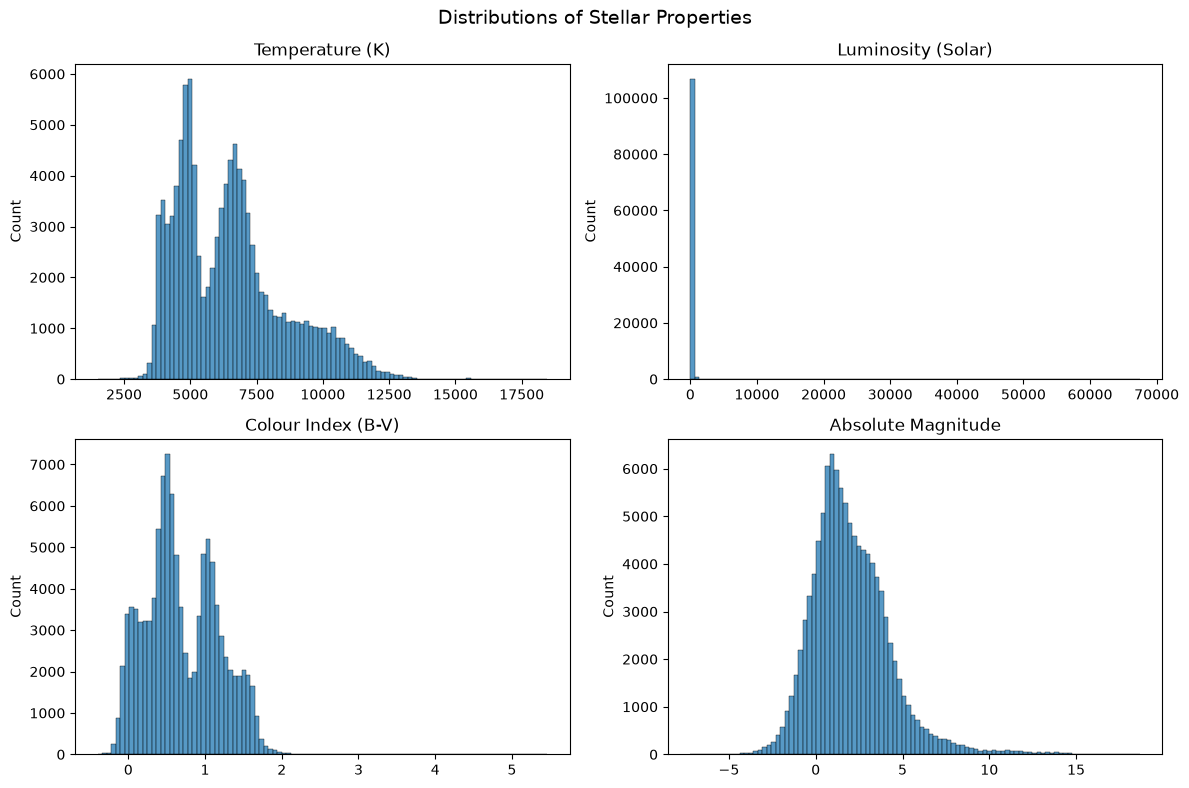

In [2]:
# Create a 2x2 grid of histograms for our four key stellar properties
# Each property is plotted with 100 bins for fine-grained shape resolution
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distributions of Stellar Properties', fontsize=14)

properties = ['temp', 'lum', 'ci', 'absmag']
titles = ['Temperature (K)', 'Luminosity (Solar)', 'Colour Index (B-V)', 'Absolute Magnitude']

# zip() pairs each property with its title, enumerate() adds a counter i
# i//2 and i%2 convert the counter into 2D grid coordinates (row, col)
for i, (prop, title) in enumerate(zip(properties, titles)):
    ax = axes[i//2, i%2]
    sns.histplot(df[prop], ax=ax, bins=100)
    ax.set_title(title)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

In [3]:
# Apply log base 10 transform to luminosity
# Required because lum is extremely right-skewed (range: 0.000003 to 67,484 solar)
# Log base 10 chosen for interpretability: each unit = 10x luminosity
df['log_lum'] = np.log10(df['lum'])

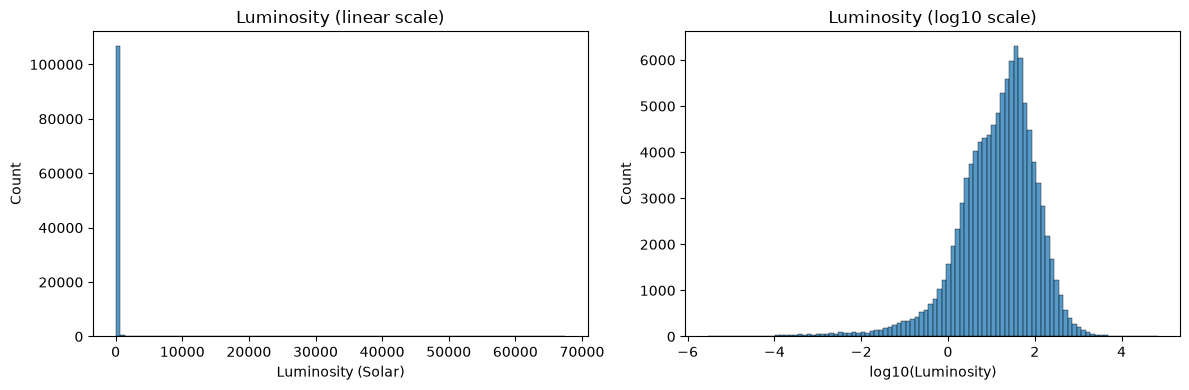

In [4]:
# Side by side comparison of linear vs log transformed luminosity
# Demonstrates why log scale is essential for this data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['lum'], ax=axes[0], bins=100)
axes[0].set_title('Luminosity (linear scale)')
axes[0].set_xlabel('Luminosity (Solar)')

sns.histplot(df['log_lum'], ax=axes[1], bins=100)
axes[1].set_title('Luminosity (log10 scale)')
axes[1].set_xlabel('log10(Luminosity)')

plt.tight_layout()
plt.show()

In [5]:
# Test log_lum for normality using the Shapiro-Wilk test
# Sample of 5000 used instead of full dataset to avoid oversensitivity
# random_state=42 ensures reproducible sampling across runs
sample = df['log_lum'].dropna().sample(5000, random_state=42)
stat, p_value = stats.shapiro(sample)

# Statistic: how close to normal (0-1, higher is better)
# P-value: probability of seeing this data if truly normal
# p < 0.05 = reject normality, but statistic of 0.93 shows it's approximately normal
print(f"Shapiro-Wilk statistic: {stat:.4f}")
print(f"P-value: {p_value:.6f}")

Shapiro-Wilk statistic: 0.9346
P-value: 0.000000


In [6]:
# Compare Shapiro-Wilk scores for raw vs log transformed luminosity
# Confirms log transform dramatically improves normality (0.05 vs 0.93)
sample_raw = df['lum'].dropna().sample(5000, random_state=42)
stat_raw, p_value_raw = stats.shapiro(sample_raw)
print(f"Raw luminosity - Shapiro-Wilk: {stat_raw:.4f}, P-value: {p_value_raw:.6f}")
print(f"Log luminosity - Shapiro-Wilk: {stat:.4f}, P-value: {p_value:.6f}")

Raw luminosity - Shapiro-Wilk: 0.0503, P-value: 0.000000
Log luminosity - Shapiro-Wilk: 0.9346, P-value: 0.000000


In [7]:
# Test absolute magnitude and colour index for normality
# Neither requires a log transform based on visual inspection
# Separate named variables prevent results being overwritten
sample_absmag = df['absmag'].dropna().sample(5000, random_state=42)
sample_ci = df['ci'].dropna().sample(5000, random_state=42)

stat_absmag, p_value_absmag = stats.shapiro(sample_absmag)
stat_ci, p_value_ci = stats.shapiro(sample_ci)

print(f"Shapiro-Wilk statistic (absmag): {stat_absmag:.4f}")
print(f"P-value (absmag): {p_value_absmag:.6f}")
print(f"Shapiro-Wilk statistic (ci): {stat_ci:.4f}")
print(f"P-value (ci): {p_value_ci:.6f}")

Shapiro-Wilk statistic (absmag): 0.9346
P-value (absmag): 0.000000
Shapiro-Wilk statistic (ci): 0.9729
P-value (ci): 0.000000


In [8]:
# Test temperature for normality
# Expected to be bimodal (two stellar populations) — confirmed visually
# Statistic still ~0.93 because the two peaks are close enough to approximate normal
sample_temp = df['temp'].dropna().sample(5000, random_state=42)
stat_temp, p_value_temp = stats.shapiro(sample_temp)
print(f"Shapiro-Wilk statistic (temp): {stat_temp:.4f}")
print(f"P-value (temp): {p_value_temp:.6f}")

Shapiro-Wilk statistic (temp): 0.9380
P-value (temp): 0.000000


## Distribution findings

| Property | Transform needed | Shapiro-Wilk | Interpretation |
|----------|-----------------|--------------|----------------|
| lum | log10 | 0.9346 | Approximately log-normal, slight left skew |
| absmag | none | 0.9346 | Approximately normal, slight right skew |
| ci | none | 0.9729 | Approximately normal, bimodal — two stellar populations |
| temp | none | 0.9380 | Approximately normal, bimodal — mirrors ci |